In [401]:
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import QuantileTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

import numpy as np


In [403]:
dataset = pd.read_csv('AmesHousing.csv')

In [405]:
dataset.shape

(2930, 82)

In [407]:
dataset.isnull().sum()

Order               0
PID                 0
MS SubClass         0
MS Zoning           0
Lot Frontage      490
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 82, dtype: int64

In [409]:
dataset.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [411]:
# dropping PID 
dataset.drop('PID', axis = 1, inplace = True)

In [413]:
dataset

,Order,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,20,RL,NaN,8885,Pave,NaN,IR1,Low,AllPub,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


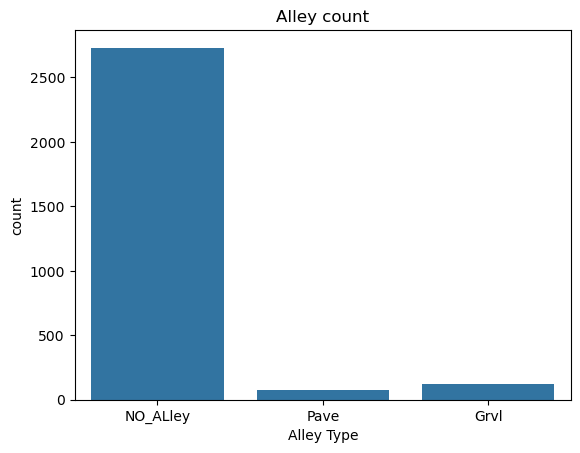

In [415]:
# For Alley plot 
dataset["Alley"] = dataset["Alley"].fillna("NO_ALley")
sns.countplot(x="Alley", data=dataset )
plt.title("Alley count")
plt.xlabel("Alley Type")
plt.ylabel("count")
plt.show()

In [416]:
dataset

,Order,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,20,RL,141.0,31770,Pave,NO_ALley,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,20,RH,80.0,11622,Pave,NO_ALley,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,20,RL,81.0,14267,Pave,NO_ALley,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,20,RL,93.0,11160,Pave,NO_ALley,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,60,RL,74.0,13830,Pave,NO_ALley,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,80,RL,37.0,7937,Pave,NO_ALley,IR1,Lvl,AllPub,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,20,RL,NaN,8885,Pave,NO_ALley,IR1,Low,AllPub,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,85,RL,62.0,10441,Pave,NO_ALley,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,20,RL,77.0,10010,Pave,NO_ALley,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


In [419]:
# Drop the alley column
dataset.drop("Alley", axis = 1, inplace= True)
dataset
#dataset['Mas Vnr Type'] = dataset['Mas Vnr Type'].fillna('')
##sns.countplot(x='Mas Vnr Type',data = dataset)
#plt.title('Mas Vnr Type')
#plt.xlabel('Mas Vnr Type')
##plt.ylabel("count")
#plt.show()

,Order,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,20,RL,141.0,31770,Pave,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,20,RL,93.0,11160,Pave,Reg,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,80,RL,37.0,7937,Pave,IR1,Lvl,AllPub,CulDSac,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,20,RL,NaN,8885,Pave,IR1,Low,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,85,RL,62.0,10441,Pave,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,20,RL,77.0,10010,Pave,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


In [421]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 80 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   MS SubClass      2930 non-null   int64  
 2   MS Zoning        2930 non-null   object 
 3   Lot Frontage     2440 non-null   float64
 4   Lot Area         2930 non-null   int64  
 5   Street           2930 non-null   object 
 6   Lot Shape        2930 non-null   object 
 7   Land Contour     2930 non-null   object 
 8   Utilities        2930 non-null   object 
 9   Lot Config       2930 non-null   object 
 10  Land Slope       2930 non-null   object 
 11  Neighborhood     2930 non-null   object 
 12  Condition 1      2930 non-null   object 
 13  Condition 2      2930 non-null   object 
 14  Bldg Type        2930 non-null   object 
 15  House Style      2930 non-null   object 
 16  Overall Qual     2930 non-null   int64  
 17  Overall Cond  

In [423]:
dataset = dataset.drop(columns = ['Roof Matl','BsmtFin Type 2','BsmtFin SF 2','Heating', 'Low Qual Fin SF','Street','Utilities','Overall Cond','Garage Area','Pool QC','Fence','Misc Feature','Misc Val','Mo Sold','Kitchen AbvGr','3Ssn Porch'])

In [425]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 64 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order           2930 non-null   int64  
 1   MS SubClass     2930 non-null   int64  
 2   MS Zoning       2930 non-null   object 
 3   Lot Frontage    2440 non-null   float64
 4   Lot Area        2930 non-null   int64  
 5   Lot Shape       2930 non-null   object 
 6   Land Contour    2930 non-null   object 
 7   Lot Config      2930 non-null   object 
 8   Land Slope      2930 non-null   object 
 9   Neighborhood    2930 non-null   object 
 10  Condition 1     2930 non-null   object 
 11  Condition 2     2930 non-null   object 
 12  Bldg Type       2930 non-null   object 
 13  House Style     2930 non-null   object 
 14  Overall Qual    2930 non-null   int64  
 15  Year Built      2930 non-null   int64  
 16  Year Remod/Add  2930 non-null   int64  
 17  Roof Style      2930 non-null   o

In [427]:
# Handling the missing value

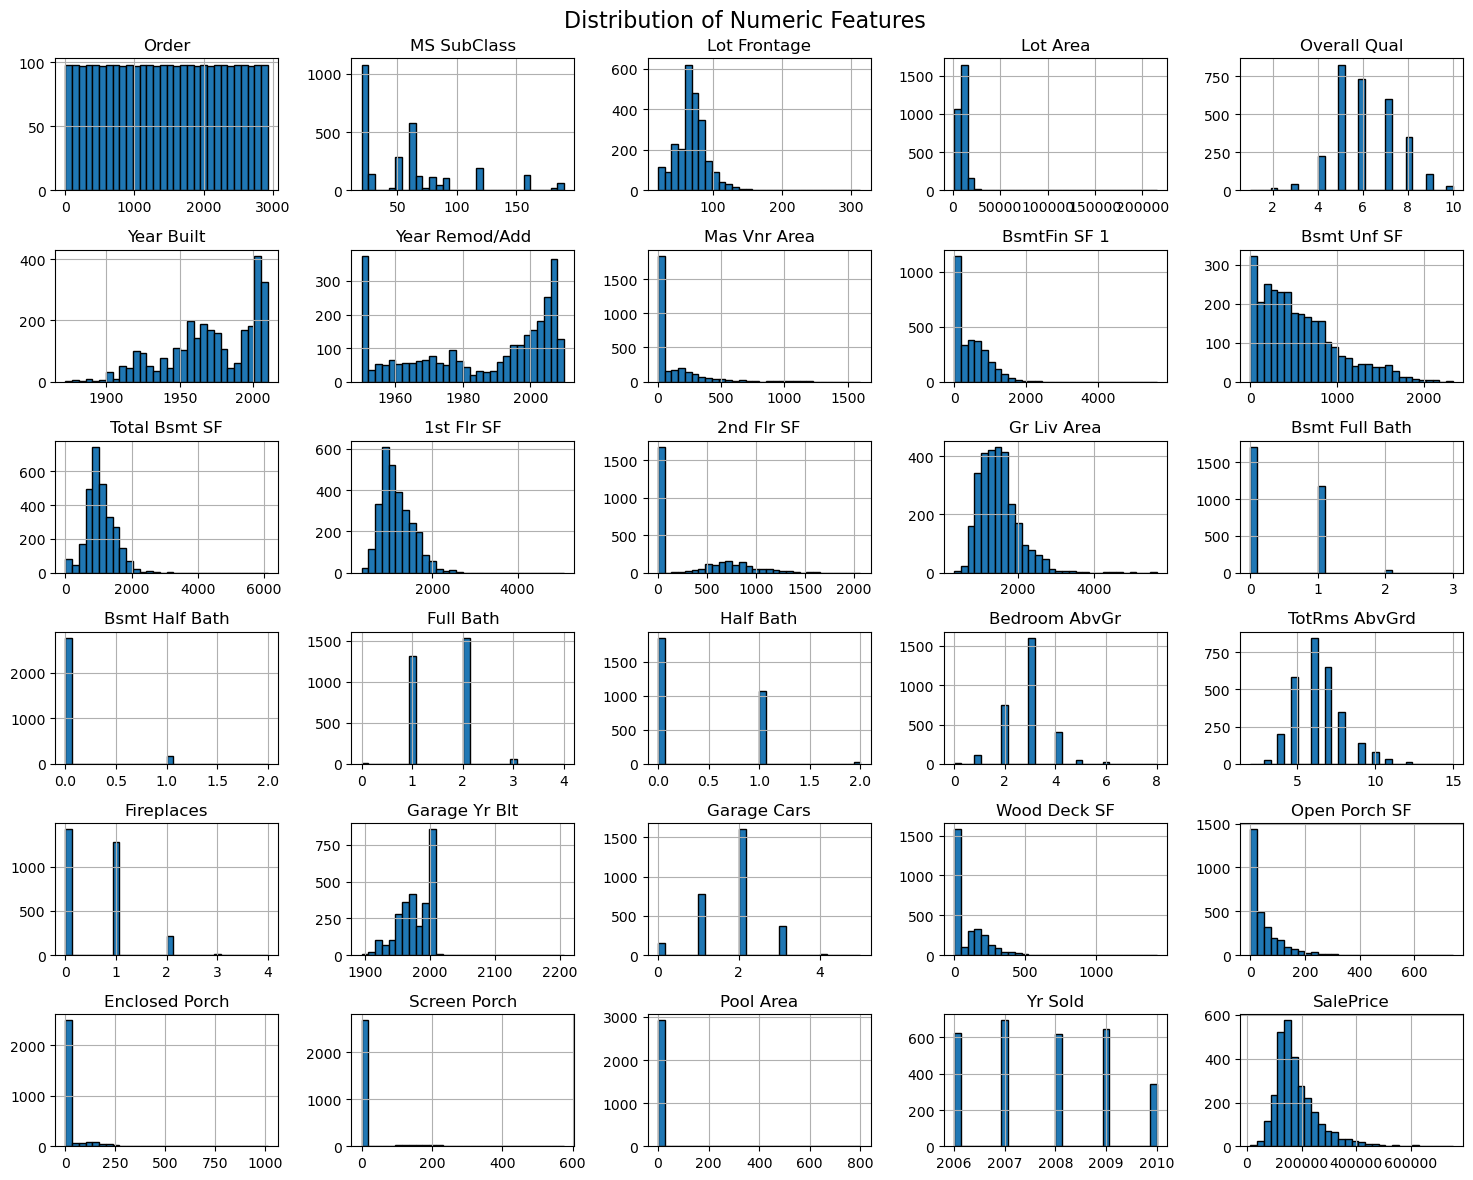

In [429]:
dataset.hist(bins=30, figsize=(15, 12), edgecolor='black')
plt.suptitle("Distribution of Numeric Features", fontsize=16)
plt.tight_layout()
plt.show()


In [430]:
# Making a new columns and find the house age 
current_year = 2025
dataset["House_Age"] = current_year - dataset['Year Built']

In [431]:
dataset["House_Age"]

0       65
1       64
2       67
3       57
4       28
        ..
2925    41
2926    42
2927    33
2928    51
2929    32
Name: House_Age, Length: 2930, dtype: int64

In [432]:
dataset["House_Age"].isnull().sum()

0

In [433]:
# change the null value with median for lot frontage
dataset['Lot Frontage'].isnull().sum()

490

C:\Users\Khushal\AppData\Local\Temp\ipykernel_26184\1201656121.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['Lot Frontage'])


<Axes: xlabel='Lot Frontage', ylabel='Density'>

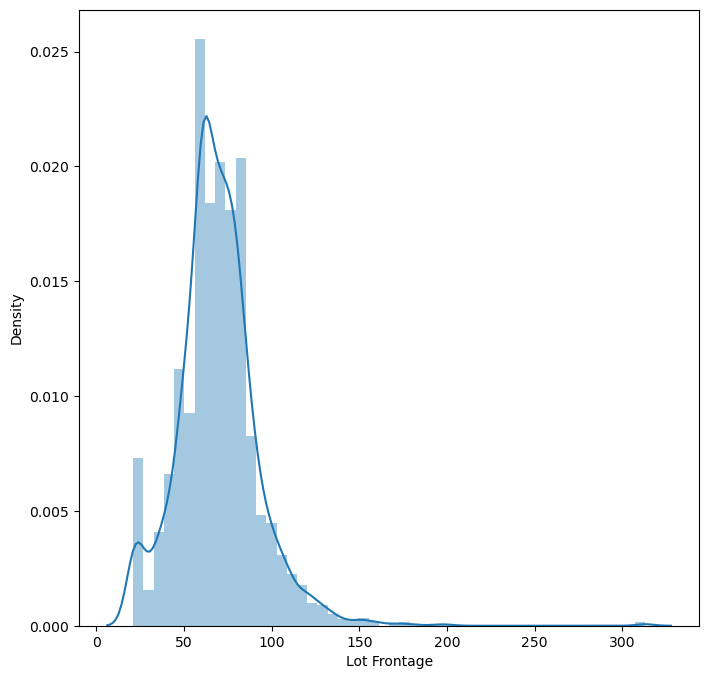

In [435]:
fig,ax = plt.subplots(figsize=(8,8))
sns.distplot(dataset['Lot Frontage'])

In [436]:
dataset['Lot Frontage']

0       141.0
1        80.0
2        81.0
3        93.0
4        74.0
        ...  
2925     37.0
2926      NaN
2927     62.0
2928     77.0
2929     74.0
Name: Lot Frontage, Length: 2930, dtype: float64

In [437]:
dataset['Lot Frontage']
dataset['Lot Frontage'].isnull().sum()

490

In [438]:
Lot_frontage_median = dataset['Lot Frontage'].median()

In [439]:
Lot_frontage_median

68.0

In [440]:
dataset['Lot Frontage'] = dataset['Lot Frontage'].fillna(Lot_frontage_median)

In [441]:
dataset['Lot Frontage']

0       141.0
1        80.0
2        81.0
3        93.0
4        74.0
        ...  
2925     37.0
2926     68.0
2927     62.0
2928     77.0
2929     74.0
Name: Lot Frontage, Length: 2930, dtype: float64

In [442]:
dataset['Mas Vnr Type'].isnull().sum()

1775

In [443]:
dataset['Mas Vnr Type']

0         Stone
1           NaN
2       BrkFace
3           NaN
4           NaN
         ...   
2925        NaN
2926        NaN
2927        NaN
2928        NaN
2929    BrkFace
Name: Mas Vnr Type, Length: 2930, dtype: object

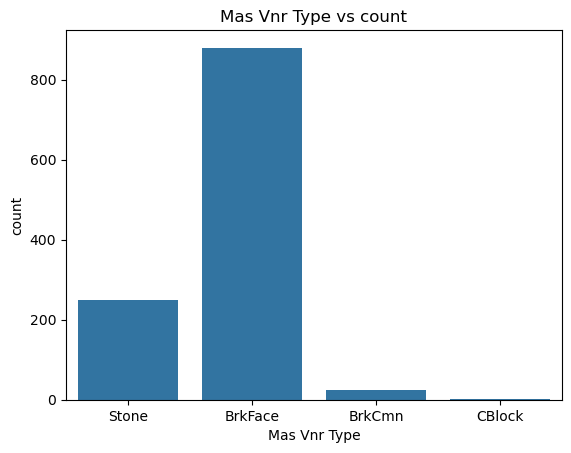

In [444]:

sns.countplot(x='Mas Vnr Type', data= dataset)
plt.xlabel('Mas Vnr Type')
plt.ylabel('count')
plt.title("Mas Vnr Type vs count")
plt.show()

In [445]:
dataset['Mas Vnr Type'] = dataset['Mas Vnr Type'].fillna("BrkFace")

In [446]:
dataset['Mas Vnr Type'].isnull().sum()

0

In [448]:
dataset['Mas Vnr Area'].isnull().sum()


23

In [449]:
dataset['Mas Vnr Area'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 2930 entries, 0 to 2929
Series name: Mas Vnr Area
Non-Null Count  Dtype  
--------------  -----  
2907 non-null   float64
dtypes: float64(1)
memory usage: 23.0 KB


C:\Users\Khushal\AppData\Local\Temp\ipykernel_26184\1326889794.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['Mas Vnr Area'])


<Axes: xlabel='Mas Vnr Area', ylabel='Density'>

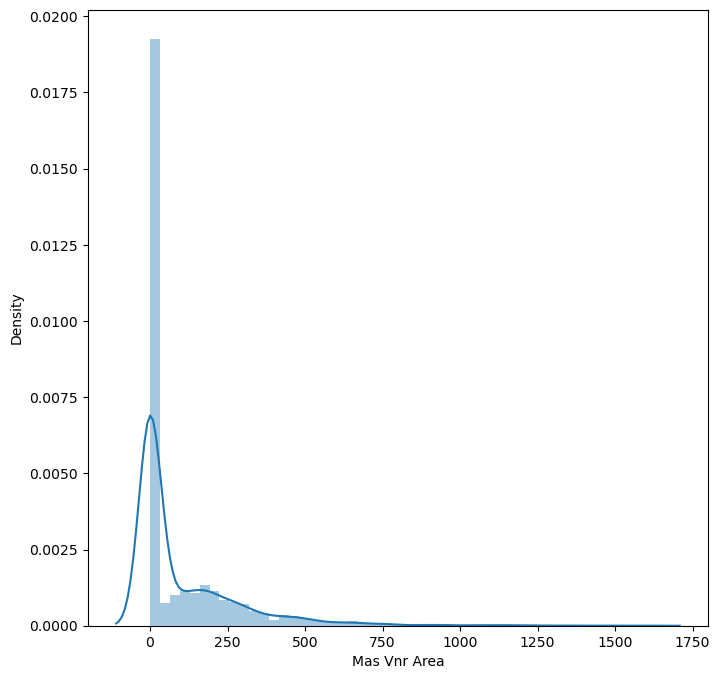

In [451]:
fig, ax = plt.subplots(figsize=(8,8))
sns.distplot(dataset['Mas Vnr Area'])

In [452]:
dataset["Mas Vnr Area"]=dataset["Mas Vnr Area"].fillna(0)

In [453]:
dataset["Mas Vnr Area"].isnull().sum()

0

In [454]:
dataset['Bsmt Exposure'].isnull().sum()

83

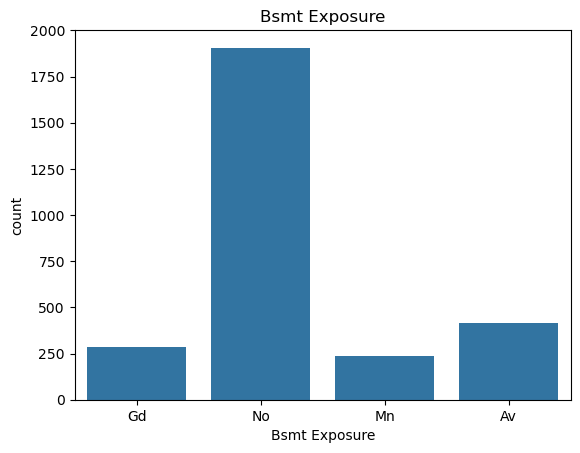

In [455]:
sns.countplot(x = 'Bsmt Exposure', data = dataset)
plt.title("Bsmt Exposure")
plt.xlabel("Bsmt Exposure")
plt.ylabel("count")
plt.show()

In [456]:
dataset['Bsmt Exposure'] = dataset['Bsmt Exposure'].fillna("No")

In [457]:
dataset['Bsmt Exposure'].isnull().sum()

0

In [458]:
dataset['BsmtFin Type 1'].isnull().sum()

80

<class 'pandas.core.series.Series'>
RangeIndex: 2930 entries, 0 to 2929
Series name: BsmtFin Type 1
Non-Null Count  Dtype 
--------------  ----- 
2850 non-null   object
dtypes: object(1)
memory usage: 23.0+ KB


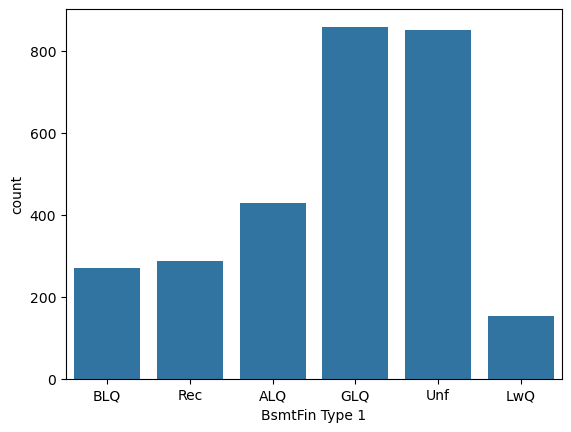

In [459]:
dataset['BsmtFin Type 1'].info()
sns.countplot(x = 'BsmtFin Type 1', data= dataset)
plt.xlabel("BsmtFin Type 1")
plt.ylabel("count")
plt.show()


In [460]:
dataset['BsmtFin Type 1'] = dataset['BsmtFin Type 1'].replace("Unf", "No_bsmt")
dataset['BsmtFin Type 1'] = dataset['BsmtFin Type 1'].fillna("No_bsmt")

<class 'pandas.core.series.Series'>
RangeIndex: 2930 entries, 0 to 2929
Series name: BsmtFin Type 1
Non-Null Count  Dtype 
--------------  ----- 
2930 non-null   object
dtypes: object(1)
memory usage: 23.0+ KB


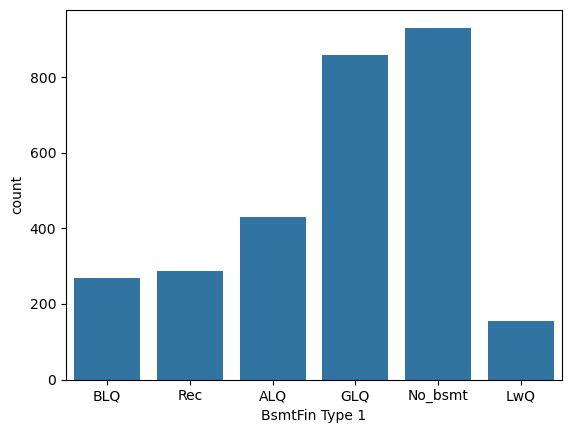

In [461]:
dataset['BsmtFin Type 1'].info()
sns.countplot(x = 'BsmtFin Type 1', data= dataset)
plt.xlabel("BsmtFin Type 1")
plt.ylabel("count")
plt.show()

In [462]:
dataset['BsmtFin SF 1'].isnull().sum()

1

C:\Users\Khushal\AppData\Local\Temp\ipykernel_26184\2723123485.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['BsmtFin SF 1'])


<Axes: xlabel='BsmtFin SF 1', ylabel='Density'>

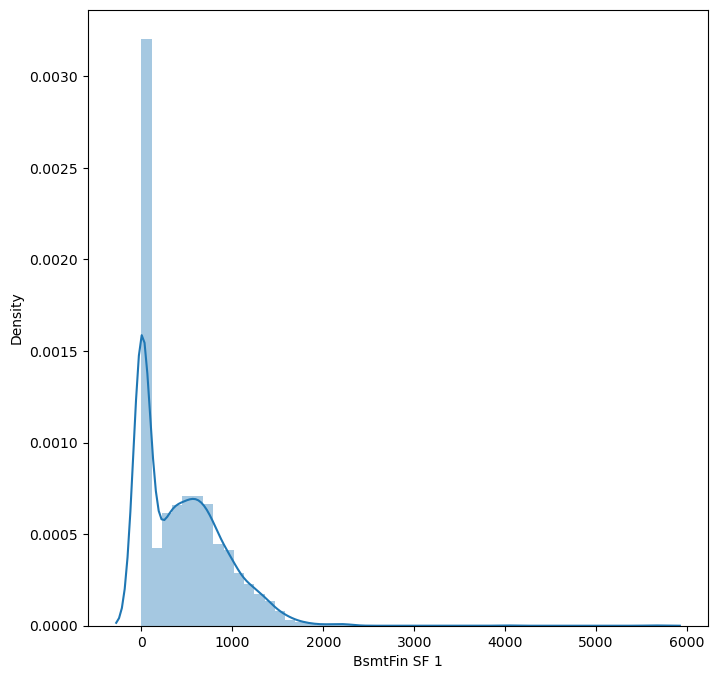

In [463]:
fig, ax = plt.subplots(figsize=(8,8))
sns.distplot(dataset['BsmtFin SF 1'])

In [464]:
dataset['BsmtFin SF 1'] = dataset["BsmtFin SF 1"].fillna(0)

In [465]:
dataset['Bsmt Unf SF'].isnull().sum()

1

C:\Users\Khushal\AppData\Local\Temp\ipykernel_26184\3946450351.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['Bsmt Unf SF'])


<Axes: xlabel='Bsmt Unf SF', ylabel='Density'>

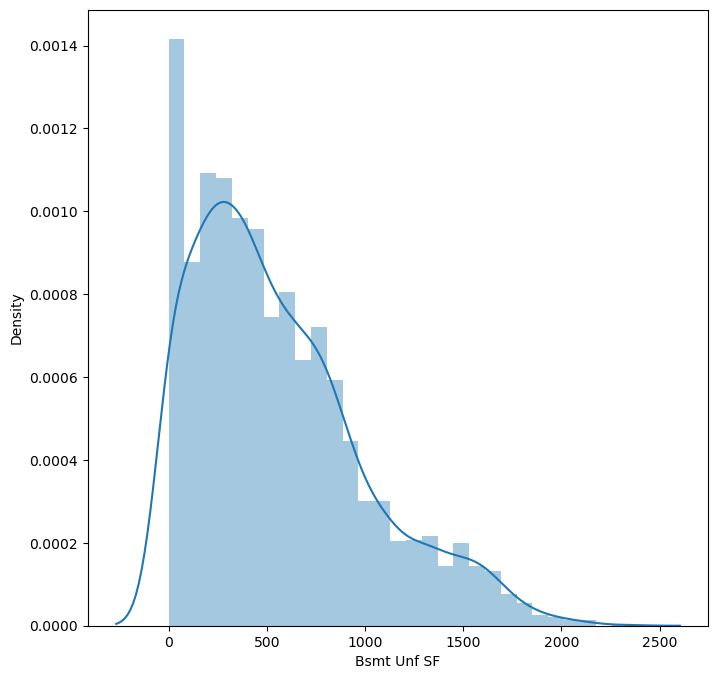

In [466]:
fig, ax = plt.subplots(figsize=(8,8))
sns.distplot(dataset['Bsmt Unf SF'])

In [467]:
dataset['Bsmt Unf SF'] = dataset['Bsmt Unf SF'].fillna(0)

In [468]:
dataset['Bsmt Unf SF'].isnull().sum()

0

In [470]:
dataset['Bsmt Qual'].isnull().sum()

80

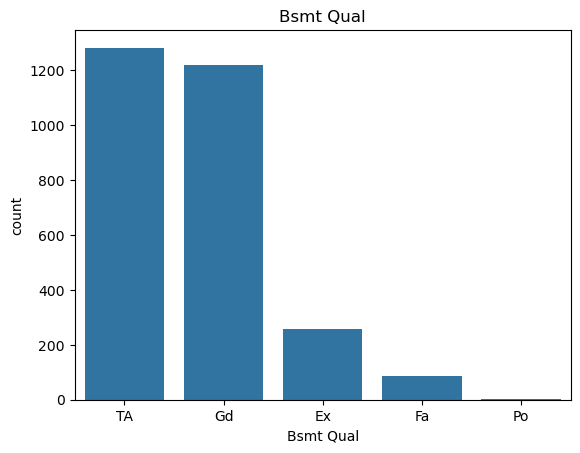

In [471]:
sns.countplot(x= 'Bsmt Qual', data = dataset)
plt.title("Bsmt Qual")
plt.xlabel("Bsmt Qual")
plt.ylabel("count")
plt.show()

In [472]:
dataset['Bsmt Qual'] = dataset['Bsmt Qual'].fillna("No_Basement")

In [473]:
dataset['Bsmt Qual'].isnull().sum()

0

In [474]:
dataset['Bsmt Cond'].isnull().sum()

80

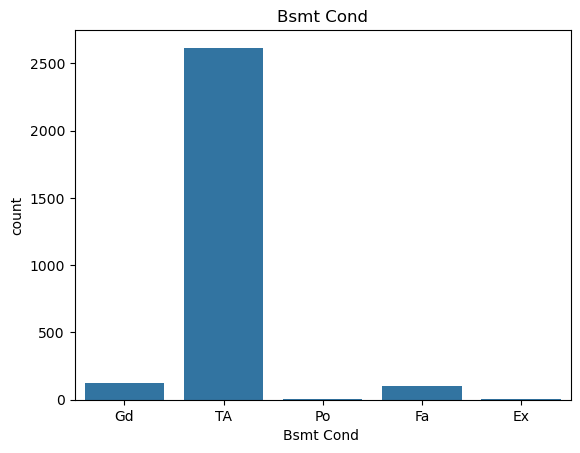

In [475]:
sns.countplot(x= "Bsmt Cond", data= dataset)
plt.title("Bsmt Cond")
plt.xlabel("Bsmt Cond ")
plt.ylabel("count")
plt.show()

In [476]:
dataset['Bsmt Cond'] = dataset['Bsmt Cond'].fillna("No_Basement")
dataset['Bsmt Cond'].isnull().sum()

0

In [477]:
dataset['Total Bsmt SF'].isnull().sum()

1

C:\Users\Khushal\AppData\Local\Temp\ipykernel_26184\267289156.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['Total Bsmt SF'])


<Axes: xlabel='Total Bsmt SF', ylabel='Density'>

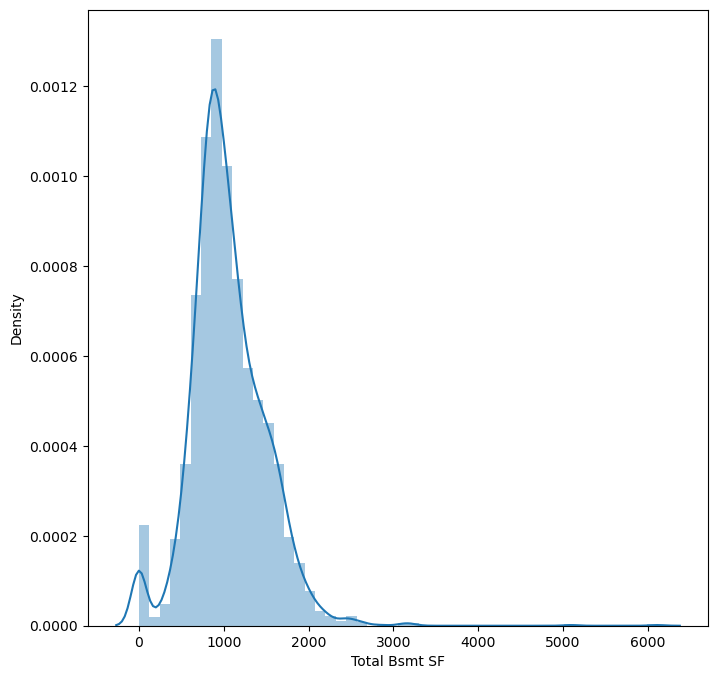

In [478]:
fig, ax = plt.subplots(figsize = (8,8))
sns.distplot(dataset['Total Bsmt SF'])

In [484]:
dataset['Total Bsmt SF'].median()

990.0

In [485]:
dataset['Total Bsmt SF'] = dataset['Total Bsmt SF'].fillna(dataset['Total Bsmt SF'].median())

In [486]:
dataset['Total Bsmt SF'].isnull().sum()

0

In [495]:
dataset['Bsmt Full Bath'].isnull().sum()

2

In [497]:
dataset['Bsmt Half Bath'].isnull().sum()

2

C:\Users\Khushal\AppData\Local\Temp\ipykernel_26184\2691791604.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['Bsmt Full Bath'])


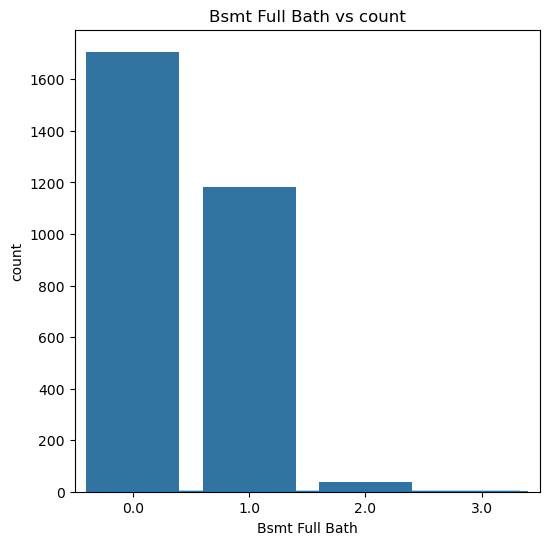

In [501]:
fig, ax = plt.subplots(figsize=(6,6))
sns.distplot(dataset['Bsmt Full Bath'])

sns.countplot(x ='Bsmt Full Bath', data=dataset)
plt.title('Bsmt Full Bath vs count')
plt.xlabel('Bsmt Full Bath')
plt.ylabel('count')
plt.show()

C:\Users\Khushal\AppData\Local\Temp\ipykernel_26184\99051741.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['Bsmt Half Bath'])


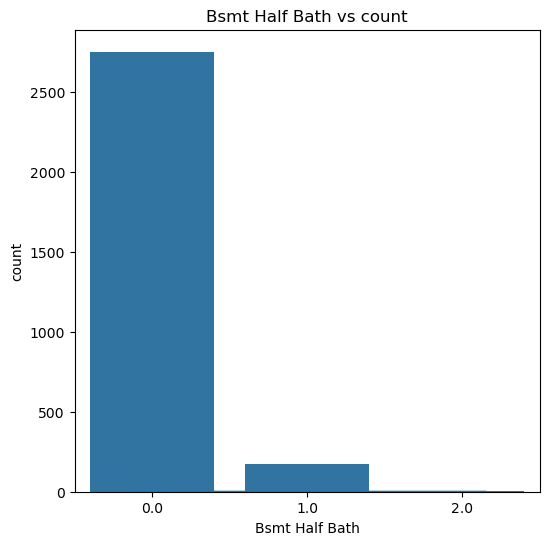

In [504]:
fig, ax = plt.subplots(figsize=(6,6))
sns.distplot(dataset['Bsmt Half Bath'])

sns.countplot(x ='Bsmt Half Bath', data=dataset)
plt.title('Bsmt Half Bath vs count')
plt.xlabel('Bsmt Half Bath')
plt.ylabel('count')
plt.show()

In [505]:
dataset['Bsmt Full Bath'] = dataset['Bsmt Full Bath'].fillna(0)
dataset['Bsmt Half Bath'] = dataset['Bsmt Half Bath'].fillna(0)

In [506]:
#dataset['Bsmt Half Bath'].isnull().sum()
dataset['Bsmt Full Bath'].isnull().sum()

0

In [512]:
dataset["Fireplaces"].isnull().sum()

0

AttributeError: module 'matplotlib.pyplot' has no attribute 'xlable'

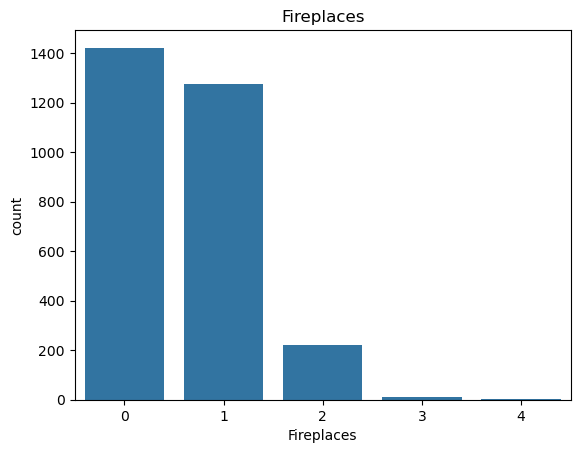

In [513]:
sns.countplot(x='Fireplaces', data=dataset)
plt.title('Fireplaces')
plt.xlable('Fireplaces')
plt.ylable("count")
plt.show()

In [ ]:
dataset["Fireplace Qu"].isnull().sum()

In [ ]:
sns.countplot(x='Fireplace Qu', data=dataset)
plt.title('Fireplace Qu')
plt.xlable('Fireplace Qu')
plt.ylable("count")
plt.show()

In [ ]:
dataset["Fireplace Qu"] = dataset["Fireplace Qu"].fillna("No_Fireplace")
dataset["Fireplace Qu"].isnull().sum()

In [ ]:
dataset['Electrical'].isnull().sum()
dataset['Electrical'].value_counts()['SBrkr']


In [ ]:
sns.countplot(x='Electrical', data = dataset)
plt.title("Electrical")
plt.xlabel("Electrical")
plt.ylabel("count")
plt.show()

In [ ]:
dataset['Electrical'] = dataset['Electrical'].fillna('SBrkr')

In [ ]:
dataset['Electrical'].value_counts()['SBrkr']


In [ ]:
dataset['Garage Type'].isnull().sum()

In [ ]:
dataset['Garage Type'].value_counts()

In [ ]:
dataset['Garage Type']= dataset['Garage Type'].fillna("No_Garage")
dataset['Garage Type'].value_counts()


In [ ]:
dataset['Garage Yr Blt'].isnull().sum()

In [ ]:
dataset['Garage Yr Blt'].value_counts()

In [ ]:
dataset['Garage Yr Blt'] = dataset['Garage Yr Blt'].fillna(0)

In [ ]:
dataset['Garage Yr Blt'].value_counts()

In [ ]:
dataset['Garage Finish'].isnull().sum()

In [ ]:
dataset['Garage Finish'].value_counts()

In [ ]:
sns.countplot(x='Garage Finish', data = dataset)
plt.title('Garage Finish')
plt.xlabel('Garage Finish')
plt.ylabel("count")
plt.show()

In [ ]:
dataset['Garage Finish'] = dataset['Garage Finish'].fillna("No_Garage")

In [ ]:
dataset['Garage Finish'].value_counts()

In [ ]:
dataset['Garage Cars'].isnull().sum()

In [ ]:
dataset['Garage Cars'].value_counts()

In [ ]:
dataset['Garage Cars'] = dataset['Garage Cars'].fillna(0)

In [ ]:
dataset['Garage Cars'].value_counts()

In [ ]:
dataset['Garage Qual'].value_counts()

In [ ]:
dataset['Garage Qual'] = dataset['Garage Qual'].fillna("No_Garage")

In [ ]:
dataset['Garage Qual'].value_counts()

In [ ]:
dataset['Garage Cond'].isnull().sum()

In [ ]:
dataset['Garage Cond'].value_counts()

In [ ]:
dataset['Garage Cond'] = dataset['Garage Cond'].fillna('No_garage')

In [ ]:
dataset['Garage Cond'].value_counts()

In [ ]:
# Distribution of target
sns.histplot(dataset['SalePrice'],kde= True)
plt.title("SalePrice Distribution")
plt.show()

In [ ]:
# Heatmap for numerical features only
corr = dataset.corr(numeric_only = True)
plt.figure(figsize=(8,8))
sns.heatmap(corr[['SalePrice']].sort_values('SalePrice', ascending = False),annot= True)
plt.title("Top Correlated Features with SalePrice")
plt.show()

<Axes: xlabel='Overall Qual', ylabel='SalePrice'>

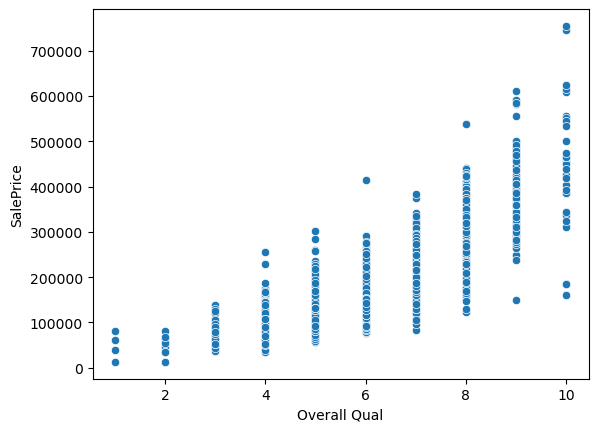

In [522]:

sns.scatterplot(data= dataset, x='Overall Qual', y = 'SalePrice' )

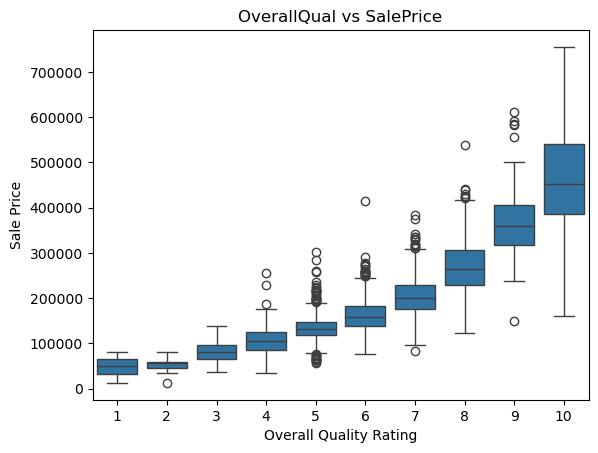

In [535]:
sns.boxplot(data=dataset, x='Overall Qual', y='SalePrice')
plt.title("OverallQual vs SalePrice")
plt.xlabel("Overall Quality Rating")
plt.ylabel("Sale Price")
plt.show()

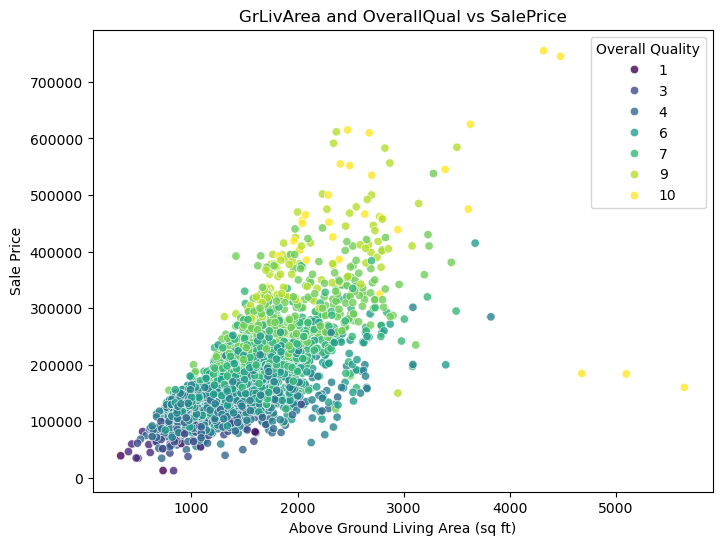

In [536]:
plt.figure(figsize=(8,6))
sns.scatterplot(data= dataset, x = 'Gr Liv Area', y = 'SalePrice', hue= 'Overall Qual', palette = 'viridis',alpha=0.8 )
plt.title('GrLivArea and OverallQual vs SalePrice')
plt.xlabel('Above Ground Living Area (sq ft)')
plt.ylabel('Sale Price')
plt.legend(title='Overall Quality')
plt.show()

<Axes: xlabel='Year Built', ylabel='SalePrice'>

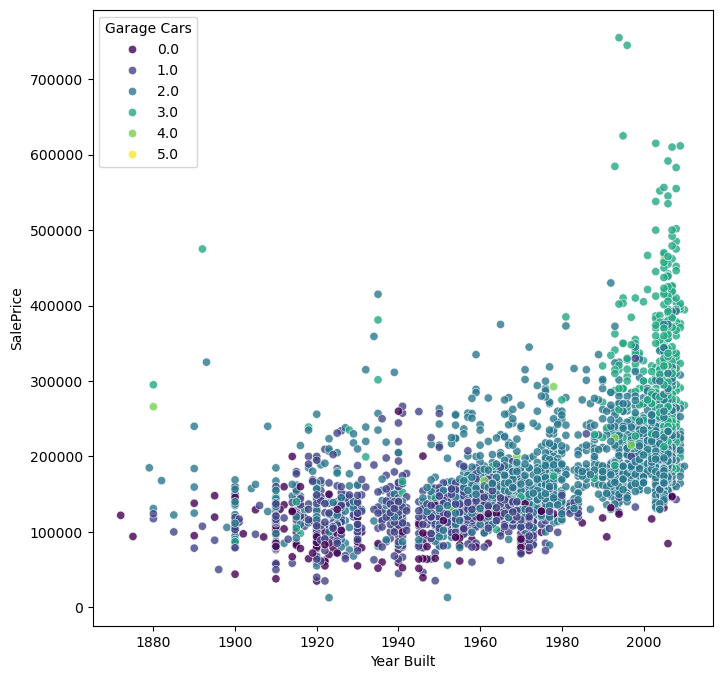

In [537]:
plt.figure(figsize= (8,8))
sns.scatterplot(data = dataset, x = 'Year Built', y= 'SalePrice' , hue= 'Garage Cars', palette= 'viridis',alpha=0.8 )

In [539]:
dataset['Gr Liv Area'].isnull().sum()
dataset["Gr Liv Area"].value_counts()

Gr Liv Area
864     41
1092    26
1040    25
1456    20
1200    18
        ..
1017     1
2350     1
2058     1
1912     1
1003     1
Name: count, Length: 1292, dtype: int64

C:\Users\Khushal\AppData\Local\Temp\ipykernel_26184\2311694196.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["Gr Liv Area"])


<Axes: xlabel='Gr Liv Area', ylabel='Density'>

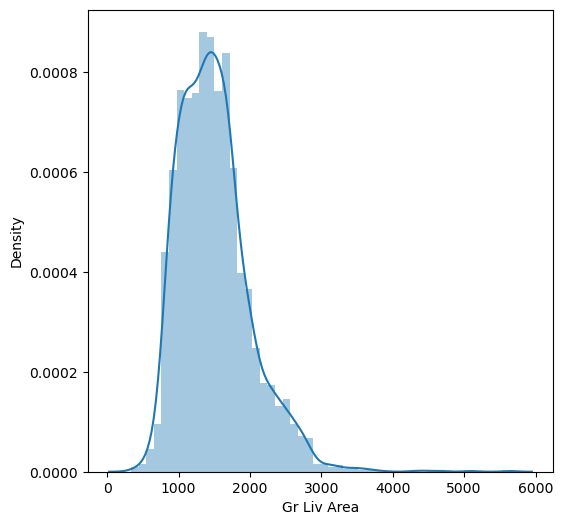

In [540]:
fig,ax = plt.subplots(figsize=(6,6))
sns.distplot(dataset["Gr Liv Area"])

In [542]:
X = dataset[['Gr Liv Area']]
qt = QuantileTransformer(output_distribution='normal', random_state=42)
X_transformed = qt.fit_transform(X)
dataset['Gr Liv Area Transformed'] = X_transformed


C:\Users\Khushal\AppData\Local\Temp\ipykernel_26184\1955610575.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["Gr Liv Area Transformed"])


<Axes: xlabel='Gr Liv Area Transformed', ylabel='Density'>

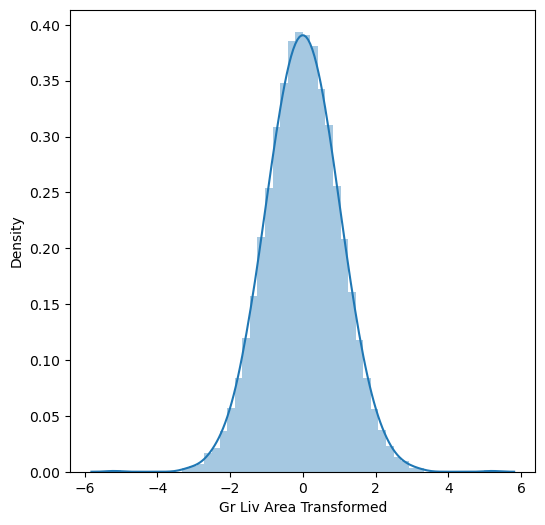

In [543]:
fig,ax = plt.subplots(figsize=(6,6))
sns.distplot(dataset["Gr Liv Area Transformed"])

C:\Users\Khushal\AppData\Local\Temp\ipykernel_26184\54276924.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['1st Flr SF'])


0       1656
1        896
2       1329
3       2110
4        928
        ... 
2925    1003
2926     902
2927     970
2928    1389
2929     996
Name: 1st Flr SF, Length: 2930, dtype: int64

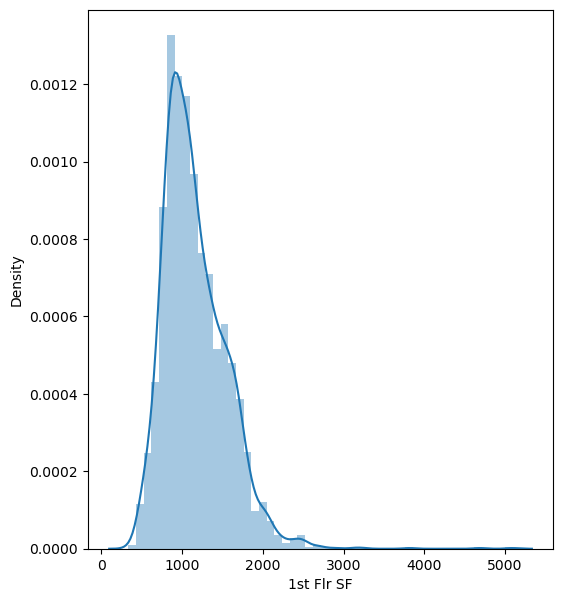

In [544]:
fig,ax = plt.subplots(figsize=(6,7))
sns.distplot(dataset['1st Flr SF'])
dataset['1st Flr SF']

In [545]:
first_St = dataset[['1st Flr SF']]
qt = QuantileTransformer(output_distribution = 'normal', random_state= 42)
first_St_transformed = qt.fit_transform(first_St)
dataset['1st Flr SF Transformed'] = first_St_transformed

C:\Users\Khushal\AppData\Local\Temp\ipykernel_26184\415044990.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['1st Flr SF Transformed'])


<Axes: xlabel='1st Flr SF Transformed', ylabel='Density'>

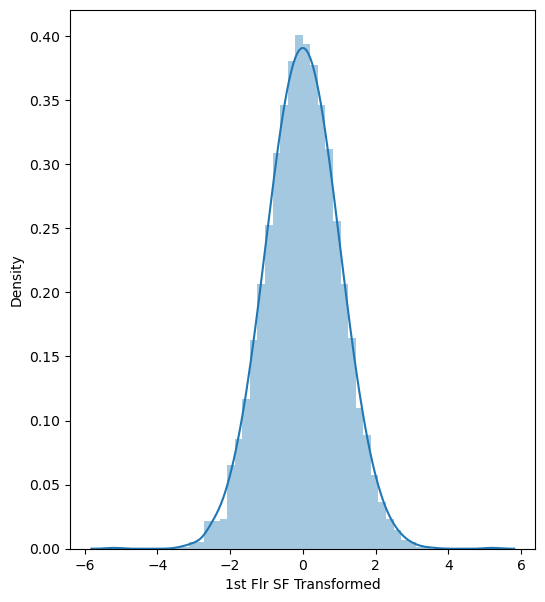

In [547]:
fig, ax = plt.subplots(figsize=(6,7))
sns.distplot(dataset['1st Flr SF Transformed'])

C:\Users\Khushal\AppData\Local\Temp\ipykernel_26184\1769421934.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['Total Bsmt SF'])


<Axes: xlabel='Total Bsmt SF', ylabel='Density'>

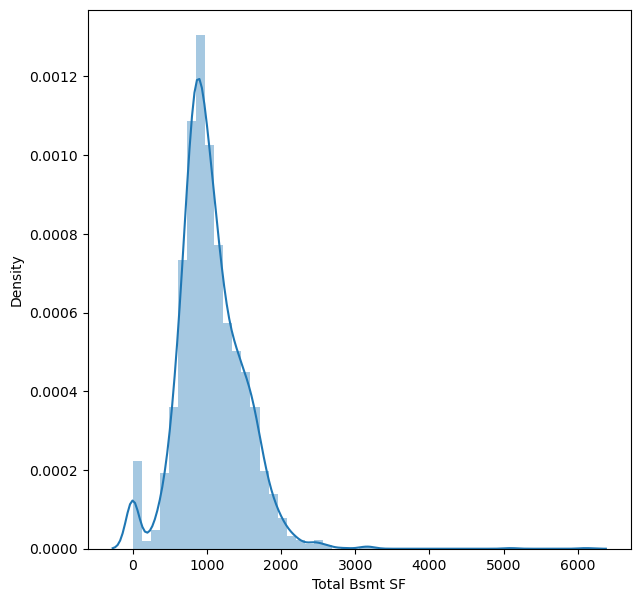

In [548]:
# Apply quantile transformation for total bsmt sf
fig, ax = plt.subplots(figsize=[7,7])
sns.distplot(dataset['Total Bsmt SF'])


In [549]:
#let's apply the quantile transformation
Total_Bsmt_Sf1 = dataset[['Total Bsmt SF']]
qt = QuantileTransformer(output_distribution='normal', random_state= 42)
Y = qt.fit_transform(Total_Bsmt_Sf1)
dataset['Total Bsmt Sf_transformed'] = Y

C:\Users\Khushal\AppData\Local\Temp\ipykernel_26184\2616852809.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['Total Bsmt Sf_transformed'])


<Axes: xlabel='Total Bsmt Sf_transformed', ylabel='Density'>

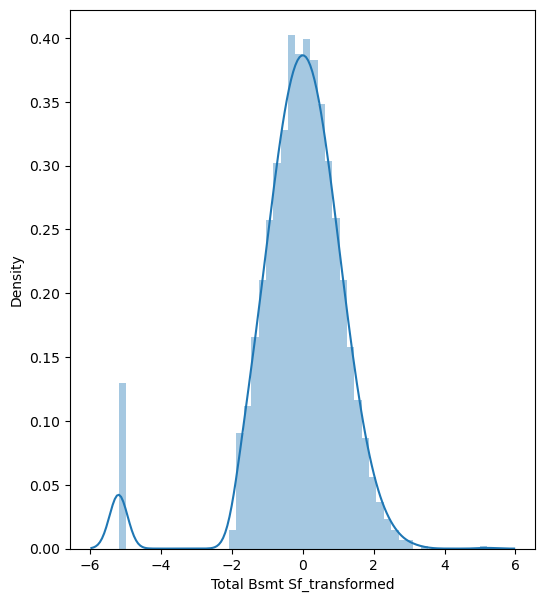

In [551]:
fig, ax = plt.subplots(figsize=(6,7))
sns.distplot(dataset['Total Bsmt Sf_transformed'])

C:\Users\Khushal\AppData\Local\Temp\ipykernel_26184\3017688162.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['Bsmt Unf SF'])


<Axes: xlabel='Bsmt Unf SF', ylabel='Density'>

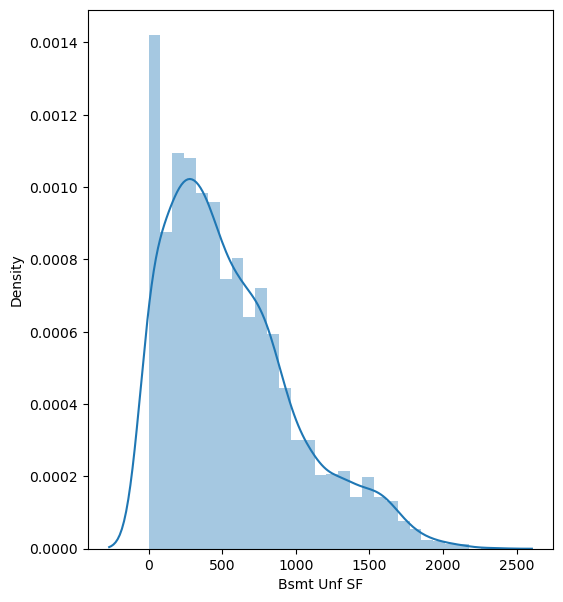

In [552]:
fig, ax = plt.subplots(figsize=(6,7))
sns.distplot(dataset['Bsmt Unf SF'])

In [553]:
Bsmt_unf_sf1 = dataset[['Bsmt Unf SF']]
qt = QuantileTransformer(output_distribution = 'normal', random_state = 42)
Z = qt.fit_transform(Bsmt_unf_sf1)
dataset['Bsmt Unf SF_transform'] = Z

C:\Users\Khushal\AppData\Local\Temp\ipykernel_26184\1252813642.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['Bsmt Unf SF_transform'])


<Axes: xlabel='Bsmt Unf SF_transform', ylabel='Density'>

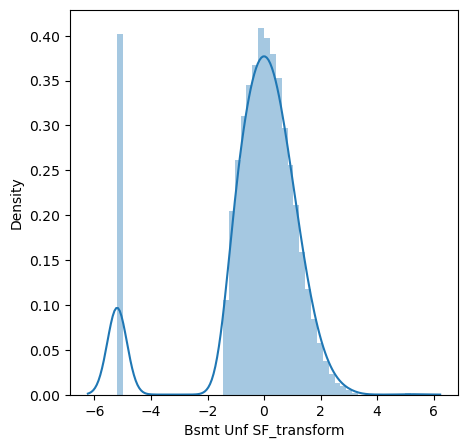

In [554]:
fig, ax = plt.subplots(figsize=(5,5))
sns.distplot(dataset['Bsmt Unf SF_transform'])

C:\Users\Khushal\AppData\Local\Temp\ipykernel_26184\2065446383.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['SalePrice'])


<Axes: xlabel='SalePrice', ylabel='Density'>

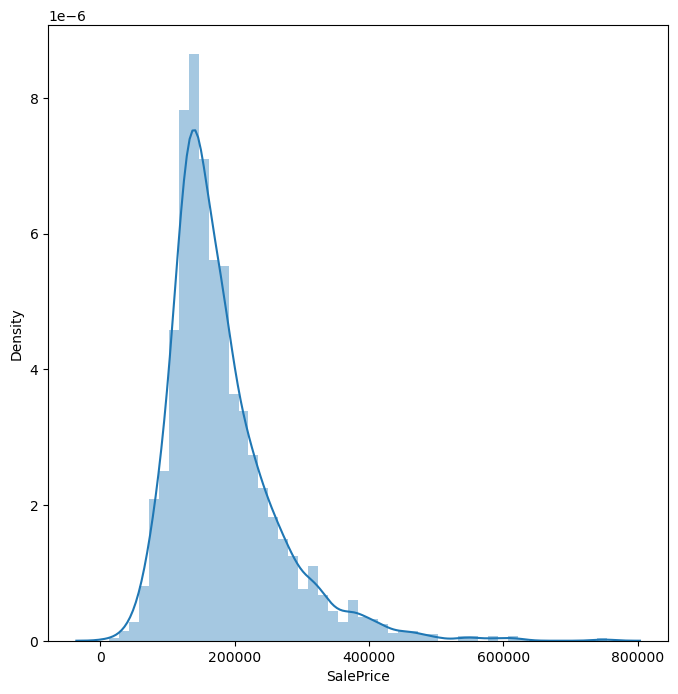

In [555]:
fig, ax = plt.subplots(figsize=(8,8))
sns.distplot(dataset['SalePrice'])

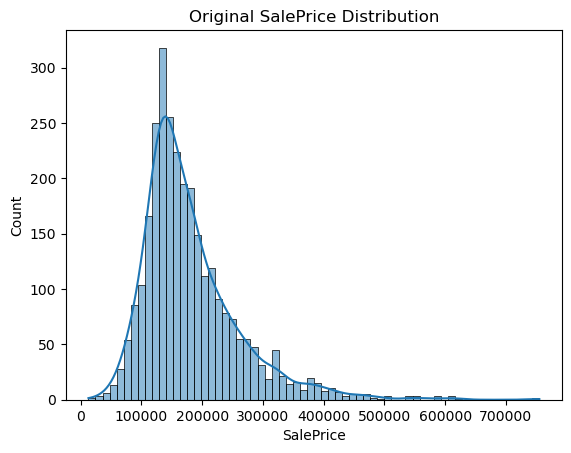

In [558]:
sns.histplot(dataset['SalePrice'], kde=True)
plt.title('Original SalePrice Distribution')
plt.show()


In [559]:
dataset['Log_SalePrice'] = np.log1p(dataset['SalePrice'])


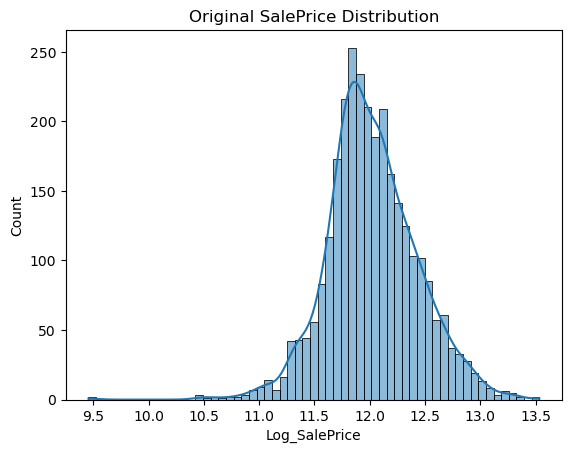

In [561]:
sns.histplot(dataset['Log_SalePrice'], kde=True)
plt.title('Original SalePrice Distribution')
plt.show()


In [563]:
dataset['Lot Area'].value_counts

<bound method IndexOpsMixin.value_counts of 0       31770
1       11622
2       14267
3       11160
4       13830
        ...  
2925     7937
2926     8885
2927    10441
2928    10010
2929     9627
Name: Lot Area, Length: 2930, dtype: int64>

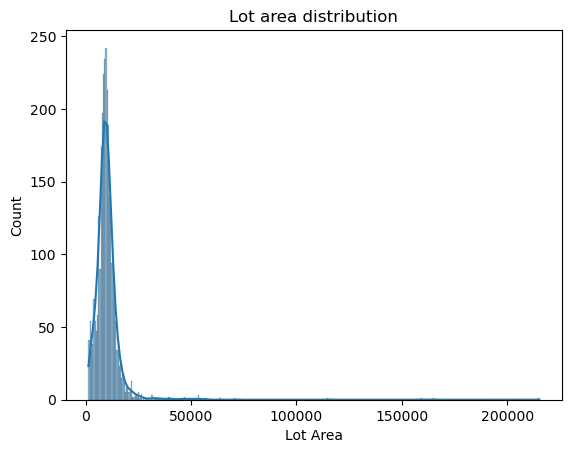

In [564]:
sns.histplot(dataset['Lot Area'], kde = True)
plt.title("Lot area distribution")
plt.show()

In [565]:
dataset['log Lot Area'] = np.log1p(dataset['Lot Area'])

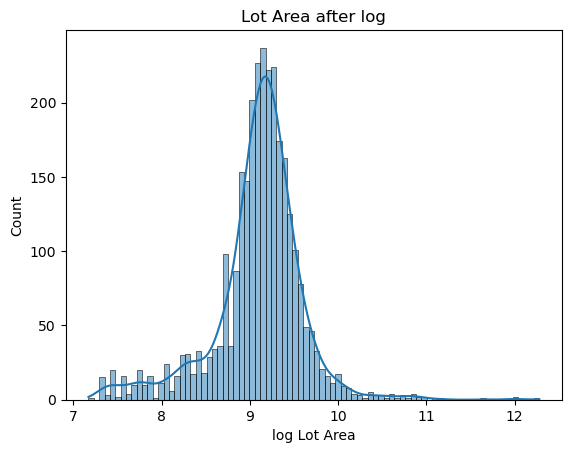

In [567]:
sns.histplot(dataset['log Lot Area'],kde = True)
plt.title('Lot Area after log')
plt.show()

In [568]:
dataset['MS SubClass'].value_counts()

MS SubClass
20     1079
60      575
50      287
120     192
30      139
160     129
70      128
80      118
90      109
190      61
85       48
75       23
45       18
180      17
40        6
150       1
Name: count, dtype: int64

In [570]:
# MS subclass data is skewed so re arrange that data into meaningful way.

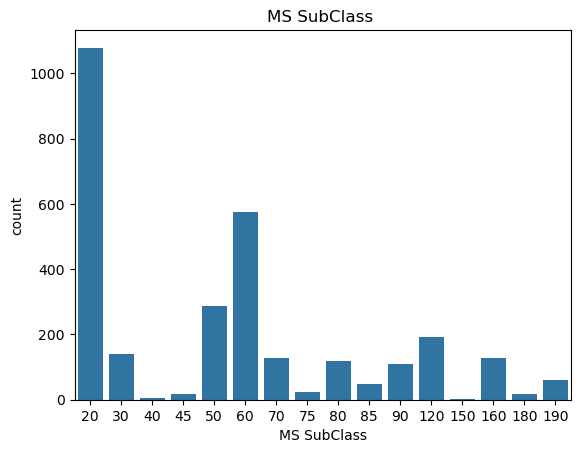

In [572]:
sns.countplot(x = 'MS SubClass', data= dataset)
plt.title("MS SubClass ")
plt.xlabel("MS SubClass")
plt.ylabel("count")
plt.show()

C:\Users\Khushal\AppData\Local\Temp\ipykernel_26184\1512938691.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=group_avg, x='MSSubClass_Group', y='SalePrice', palette='viridis')


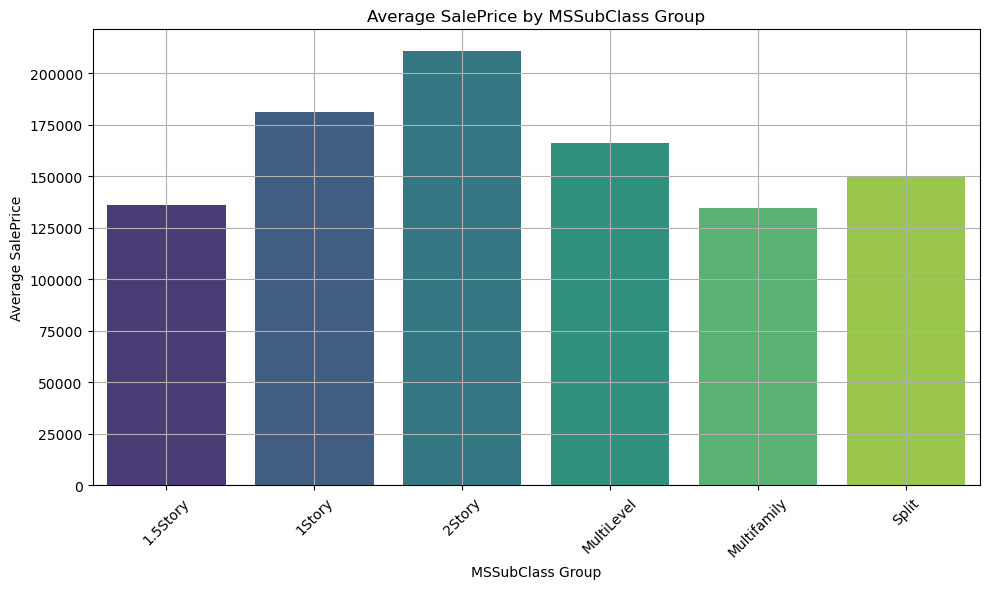

In [576]:

# Map MSSubClass numeric codes to readable labels
mapping = {
    20: '1Story_New',
    30: '1Story_Old',
    40: '1Story_Attic',
    45: '1.5Story_Unfinished',
    50: '1.5Story_Finished',
    60: '2Story_New',
    70: '2Story_Old',
    75: '2.5Story_AllAges',
    80: 'Split_MultiLevel',
    85: 'Split_Foyer',
    90: 'Duplex',
    120: '1Story_PUD',
    150: '1.5Story_PUD',
    160: '2Story_PUD',
    180: 'MultiLevel_PUD',
    190: 'Conversion_2to1Fam'
}

dataset['MSSubClass_Label'] = dataset['MS SubClass'].map(mapping)

#Group into symmetric categories
def subclass_group(label):
    if pd.isnull(label):
        return 'Unknown'
    elif '1Story' in label:
        return '1Story'
    elif '1.5Story' in label:
        return '1.5Story'
    elif '2Story' in label:
        return '2Story'
    elif '2.5Story' in label or 'MultiLevel' in label:
        return 'MultiLevel'
    elif 'Split' in label:
        return 'Split'
    elif 'Duplex' in label or 'Conversion' in label:
        return 'Multifamily'
    else:
        return 'Other'

dataset['MSSubClass_Group'] = dataset['MSSubClass_Label'].apply(subclass_group)

# we can safely use MSSubClass_Group
# Group by the symmetric group and calculate mean SalePrice
group_avg = dataset.groupby('MSSubClass_Group')['SalePrice'].mean().reset_index()

#Visualize
plt.figure(figsize=(10,6))
sns.barplot(data=group_avg, x='MSSubClass_Group', y='SalePrice', palette='viridis')

plt.title("Average SalePrice by MSSubClass Group")
plt.xlabel("MSSubClass Group")
plt.ylabel("Average SalePrice")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


In [577]:

dataset

,Order,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Lot Shape,Land Contour,Lot Config,Land Slope,Neighborhood,...,SalePrice,House_Age,Gr Liv Area Transformed,1st Flr SF Transformed,Total Bsmt Sf_transformed,Bsmt Unf SF_transform,Log_SalePrice,log Lot Area,MSSubClass_Label,MSSubClass_Group
0,1,20,RL,141.0,31770,IR1,Lvl,Corner,Gtl,NAmes,...,215000,65,0.465405,1.236652,0.235509,-0.051460,12.278398,10.366309,1Story_New,1Story
1,2,20,RH,80.0,11622,Reg,Lvl,Inside,Gtl,NAmes,...,105000,64,-1.384628,-0.595437,-0.321611,-0.520661,11.561725,9.360741,1Story_New,1Story
2,3,20,RL,81.0,14267,IR1,Lvl,Corner,Gtl,NAmes,...,172000,67,-0.249131,0.551294,0.720036,-0.139710,12.055256,9.565775,1Story_New,1Story
3,4,20,RL,93.0,11160,Reg,Lvl,Corner,Gtl,NAmes,...,244000,57,1.236652,2.119300,2.225955,1.071784,12.404928,9.320181,1Story_New,1Story
4,5,60,RL,74.0,13830,IR1,Lvl,Inside,Gtl,Gilbert,...,189900,28,0.393598,-0.480839,-0.182928,-0.969427,12.154258,9.534668,2Story_New,2Story
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,80,RL,37.0,7937,IR1,Lvl,CulDSac,Gtl,Mitchel,...,142500,41,-1.033443,-0.238445,0.030467,-0.802226,11.867104,8.979417,Split_MultiLevel,MultiLevel
2926,2927,20,RL,68.0,8885,IR1,Low,Inside,Mod,Mitchel,...,131000,42,-1.363353,-0.573115,-0.392492,-0.611165,11.782960,9.092232,1Story_New,1Story
2927,2928,85,RL,62.0,10441,Reg,Lvl,Inside,Gtl,Mitchel,...,132000,33,-1.135284,-0.332198,-0.243255,0.219982,11.790565,9.253591,Split_Foyer,Split
2928,2929,20,RL,77.0,10010,Reg,Lvl,Inside,Mod,Mitchel,...,170000,51,-0.106841,0.678472,0.830234,-0.754664,12.043560,9.211440,1Story_New,1Story


In [580]:
dataset['MSSubClass_Group'].value_counts()

MSSubClass_Group
1Story         1416
2Story          832
1.5Story        306
Multifamily     170
MultiLevel      158
Split            48
Name: count, dtype: int64

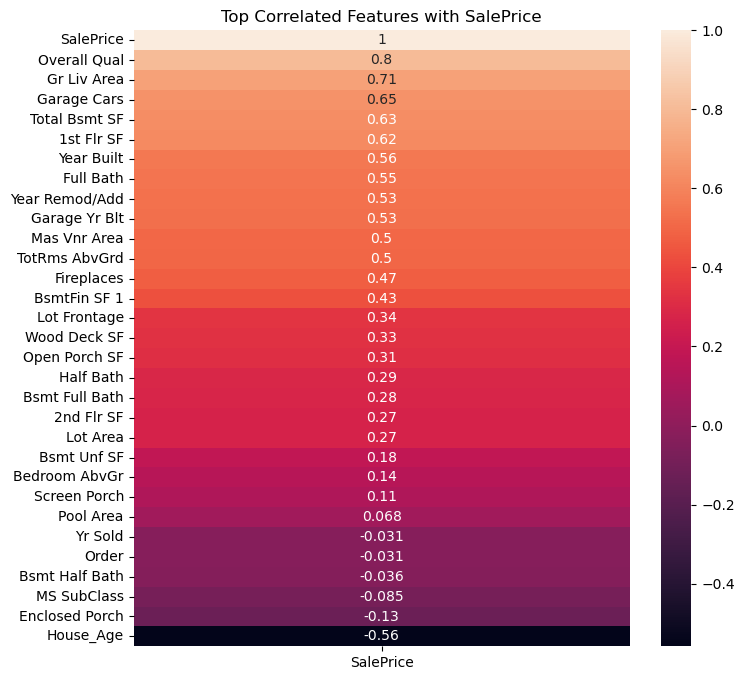

In [582]:
heat = dataset.corr(numeric_only= True)
plt.figure(figsize=(8,8))
sns.heatmap(corr[['SalePrice']].sort_values('SalePrice', ascending = False),annot= True)
plt.title("Top Correlated Features with SalePrice")
plt.show()

In [584]:
# Apply one hot encoding on MS zoning
dataset = pd.get_dummies(dataset, columns=['MS Zoning'], drop_first = True)

In [585]:
# Apply one hot encoding on 
dataset = pd.get_dummies(dataset, columns = ['Lot Shape'], drop_first = True)

In [589]:
dataset = pd.get_dummies(dataset, columns = ['Land Contour','Lot Config','Land Slope','Neighborhood','Condition 1','Condition 2','Bldg Type','House Style','Roof Style'], drop_first = True)

In [591]:
dataset = pd.get_dummies(dataset, columns=['Exterior 1st','Exterior 2nd','Mas Vnr Type','Foundation','Bsmt Exposure','BsmtFin Type 1','Electrical','Garage Type','Garage Finish','Paved Drive','Sale Type','Sale Condition'], drop_first=True)

In [597]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Columns: 200 entries, Order to Sale Condition_Partial
dtypes: bool(150), float64(15), int64(22), object(13)
memory usage: 1.5+ MB


In [600]:
dataset['Exter Qual_encode'] = LabelEncoder().fit_transform(dataset['Exter Qual'])



In [602]:
dataset.columns

Index(['Order', 'MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual',
       'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'Exter Qual',
       'Exter Cond',
       ...
       'Sale Type_New', 'Sale Type_Oth', 'Sale Type_VWD', 'Sale Type_WD ',
       'Sale Condition_AdjLand', 'Sale Condition_Alloca',
       'Sale Condition_Family', 'Sale Condition_Normal',
       'Sale Condition_Partial', 'Exter Qual_encode'],
      dtype='object', length=201)

In [606]:
# For Improvment

In [608]:
kp = dataset.corr(numeric_only = True)

In [609]:
kp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 188 entries, Order to Exter Qual_encode
Columns: 188 entries, Order to Exter Qual_encode
dtypes: float64(188)
memory usage: 281.7+ KB


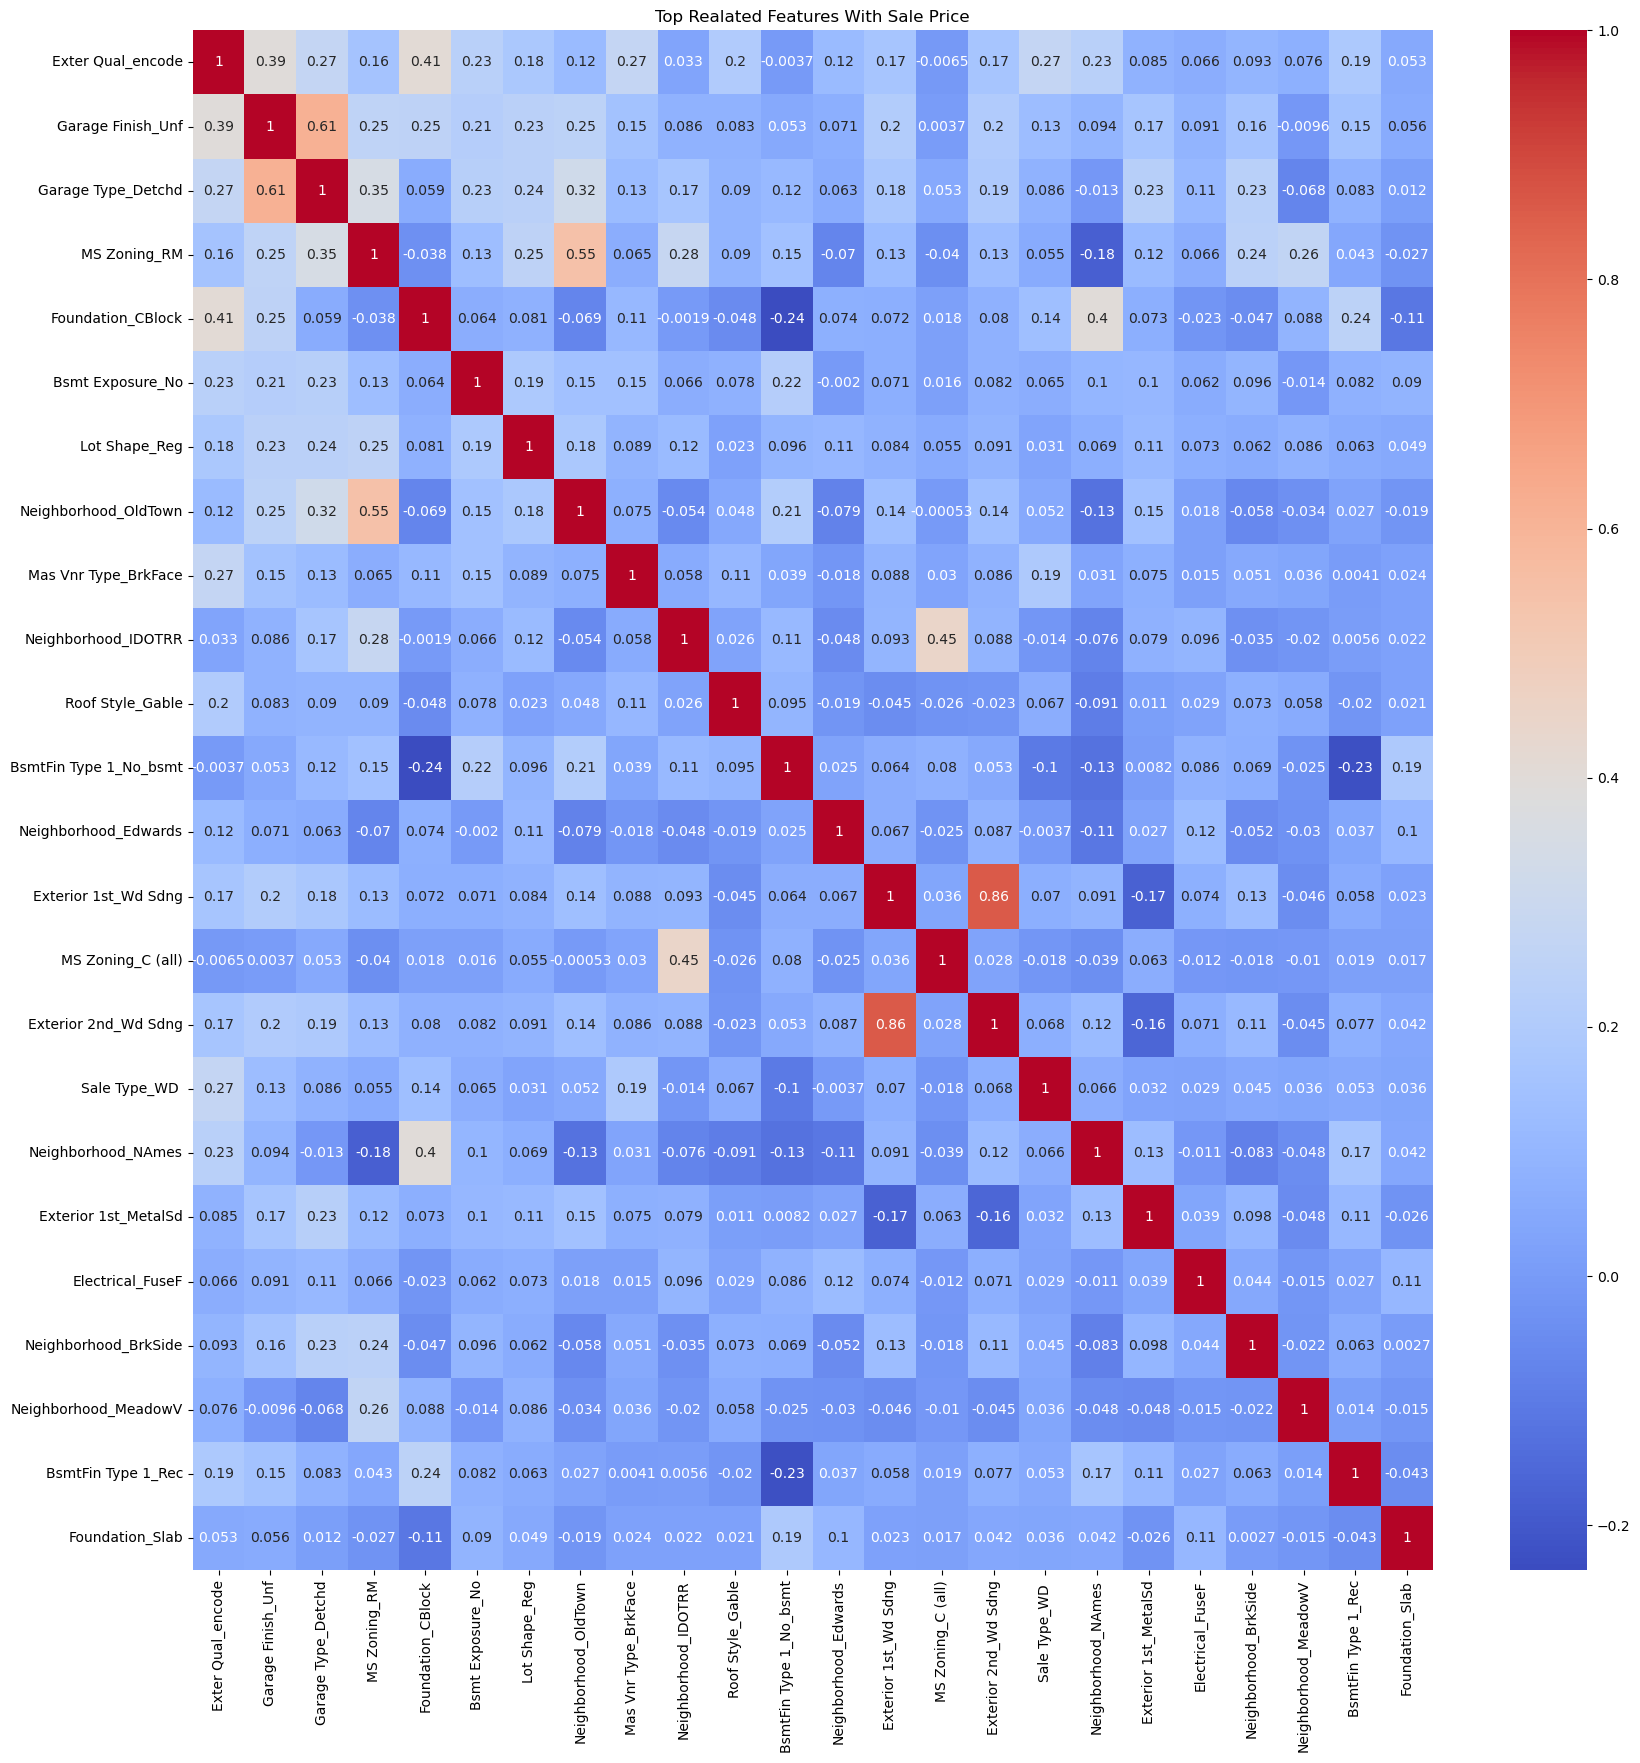

In [610]:
plt.figure(figsize = (20,20))
sorted_corr = kp['Log_SalePrice'].sort_values(ascending=True)
top_features = kp[sorted_corr.index[1:25]].loc[sorted_corr.index[1:25]]
sns.heatmap(top_features, annot=True, cmap='coolwarm')
plt.title("Top Realated Features With Sale Price")
plt.show()

In [611]:
# Correlation matrix
kp = dataset.corr(numeric_only = True)
correlation_matrix = kp.corr()

# Correlation with target variable
target_corr = correlation_matrix['Log_SalePrice']

# Select features with absolute correlation > 0.3 (excluding the target itself)
moderate_strong_corr = target_corr[abs(target_corr) > 0.3].drop('Log_SalePrice')

# Print features
print("Features with correlation > 0.3 with Log_SalePrice:\n")
print(moderate_strong_corr)

# Create a filtered DataFrame
selected_features_03 = list(moderate_strong_corr.index)
df_selected_03 = kp[selected_features_03 + ['Log_SalePrice']]


Features with correlation > 0.3 with Log_SalePrice:

Lot Frontage              0.686422
Lot Area                  0.523792
Overall Qual              0.979273
Year Built                0.877692
Year Remod/Add            0.892356
                            ...   
Sale Type_New             0.685875
Sale Type_WD             -0.508682
Sale Condition_Normal    -0.420723
Sale Condition_Partial    0.681786
Exter Qual_encode        -0.917932
Name: Log_SalePrice, Length: 94, dtype: float64


# Splitting the dataset into train and testing part

In [627]:
dataset['SalePrice']

0       215000
1       105000
2       172000
3       244000
4       189900
         ...  
2925    142500
2926    131000
2927    132000
2928    170000
2929    188000
Name: SalePrice, Length: 2930, dtype: int64

In [628]:
df_numeric = kp #.select_dtypes(exclude='object')


In [629]:
#plt.figure()
#df_numeric.boxplot([Log_SalePrice])

In [634]:
X = df_numeric.drop(['SalePrice', 'Log_SalePrice'], axis=1)
Y = df_numeric['Log_SalePrice']

In [635]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2, random_state = 2)

In [636]:
Y

Order                    -0.028814
MS SubClass              -0.070744
Lot Frontage              0.330226
Lot Area                  0.255032
Overall Qual              0.825645
                            ...   
Sale Condition_Alloca    -0.027826
Sale Condition_Family    -0.036946
Sale Condition_Normal    -0.083378
Sale Condition_Partial    0.322623
Exter Qual_encode        -0.576506
Name: Log_SalePrice, Length: 188, dtype: float64

In [637]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [639]:
print(dataset.columns.tolist())

['Order', 'MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Bsmt Qual', 'Bsmt Cond', 'BsmtFin SF 1', 'Bsmt Unf SF', 'Total Bsmt SF', 'Heating QC', 'Central Air', '1st Flr SF', '2nd Flr SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu', 'Garage Yr Blt', 'Garage Cars', 'Garage Qual', 'Garage Cond', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', 'Screen Porch', 'Pool Area', 'Yr Sold', 'SalePrice', 'House_Age', 'Gr Liv Area Transformed', '1st Flr SF Transformed', 'Total Bsmt Sf_transformed', 'Bsmt Unf SF_transform', 'Log_SalePrice', 'log Lot Area', 'MSSubClass_Label', 'MSSubClass_Group', 'MS Zoning_C (all)', 'MS Zoning_FV', 'MS Zoning_I (all)', 'MS Zoning_RH', 'MS Zoning_RL', 'MS Zoning_RM', 'Lot Shape_IR2', 'Lot Shape_IR3', 'Lot Shape_Reg', 'Land Contour_HLS', 'Land Contour_Low

In [666]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


model = RandomForestRegressor(n_estimators=150, random_state=42)
model.fit(X_train_scaled, Y_train)
y_pred = model.predict(X_test_scaled)

print("RMSE:", mean_squared_error(Y_test, y_pred, squared=False))



RMSE: 0.0786882552038615


C:\Users\Khushal\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [645]:
from sklearn.metrics import r2_score

r2_rf = r2_score(Y_test, y_pred)
print("Random Forest R² Score:", r2_rf)


Random Forest R² Score: 0.9412800693257708


In [650]:



xgb = XGBRegressor(n_estimators=150, learning_rate=0.1, max_depth=6, random_state=42)


xgb.fit(X_train, Y_train)
y_pred_log = xgb.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(Y_test)

rmse = mean_squared_error(y_actual, y_pred, squared=False)
r2 = r2_score(y_actual, y_pred)

print(" XGBoost RMSE:", rmse)
print(" XGBoost R² Score:", r2)


 XGBoost RMSE: 0.1636623827976249
 XGBoost R² Score: 0.8724997878249814


C:\Users\Khushal\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


📝 Machine Learning Model Evaluation Report

Project: Regression Model Comparison (Random Forest vs XGBoost) on AmesHousing
Author: Khushal
Date: July 2, 2025

📌 Objective:
To evaluate and compare the performance of two regression models—Random Forest and XGBoost—using RMSE and R² metrics, and determine the most accurate model for predicting the target variable.

📊 Model Performance Metrics:

| Metric              | Random Forest          | XGBoost                 |
|---------------------|------------------------|-------------------------|
| RMSE                | 0.0831                 | 0.1638                  |
| R² Score            | 0.9308 (93.08%)        | 0.8804 (88.04%)         |
| Accuracy Estimate   | ~93% (Very High)       | ~88% (High)             |
| Error Interpretation| Very Low               | Moderate                |

✅ Evaluation Summary:
- Random Forest demonstrates superior performance with lower prediction error and higher R².
- XGBoost performs well but does not outperform Random Forest.
- Random Forest is the recommended model for deployment.

📌 Recommendation:
✅ Proceed with Random Forest for production use. It offers excellent predictive accuracy and minimal error, making it well-suited for business decision-making and integration.

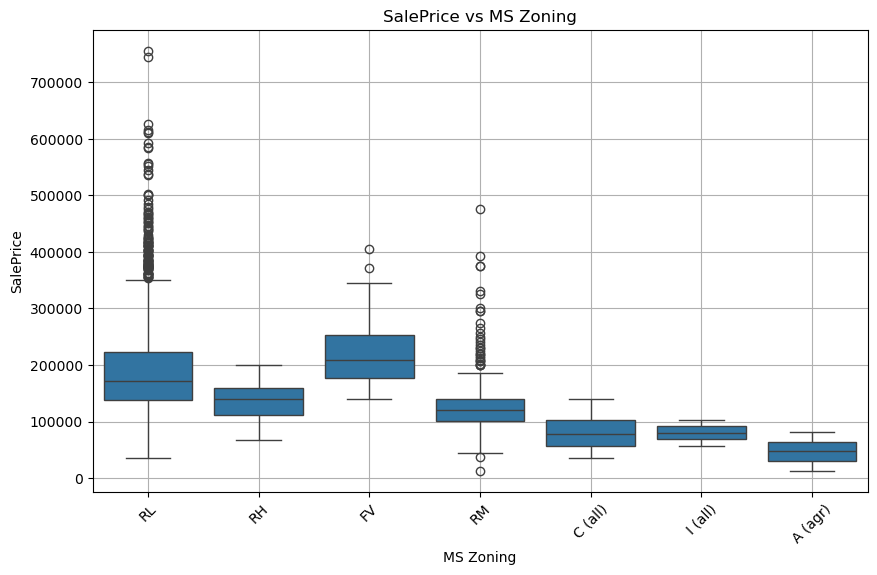

In [430]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='MS Zoning', y='SalePrice')
plt.title("SalePrice vs MS Zoning")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [467]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 69 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Order                      2930 non-null   int64  
 1   MS SubClass                2930 non-null   int64  
 2   MS Zoning                  2930 non-null   object 
 3   Lot Frontage               2930 non-null   float64
 4   Lot Area                   2930 non-null   int64  
 5   Lot Shape                  2930 non-null   object 
 6   Land Contour               2930 non-null   object 
 7   Lot Config                 2930 non-null   object 
 8   Land Slope                 2930 non-null   object 
 9   Neighborhood               2930 non-null   object 
 10  Condition 1                2930 non-null   object 
 11  Condition 2                2930 non-null   object 
 12  Bldg Type                  2930 non-null   object 
 13  House Style                2930 non-null   objec

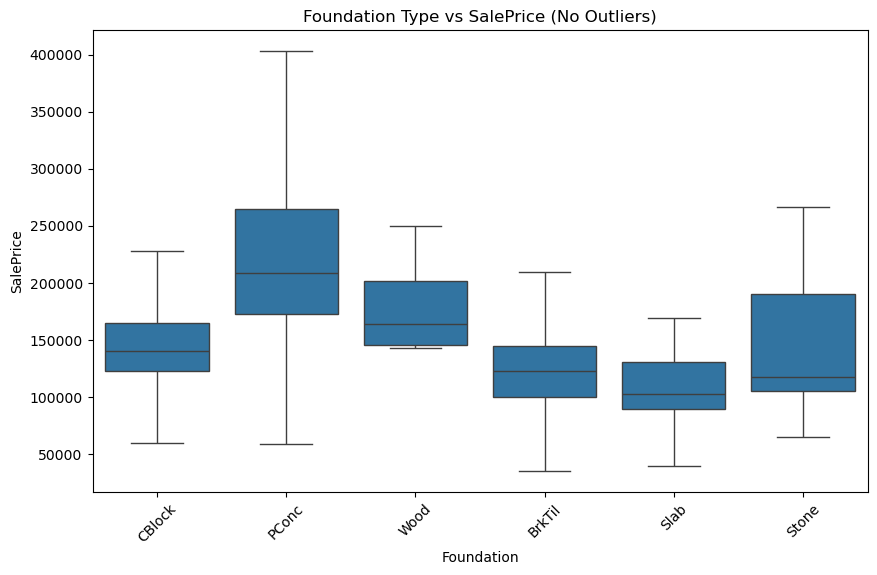

In [188]:

plt.figure(figsize=(10,6))
sns.boxplot(data=dataset, x='Foundation', y='SalePrice', showfliers=False)
plt.title("Foundation Type vs SalePrice (No Outliers)")
plt.xticks(rotation=45)
plt.show()


In [191]:
dataset['MS SubClass'].isnull().sum()


0

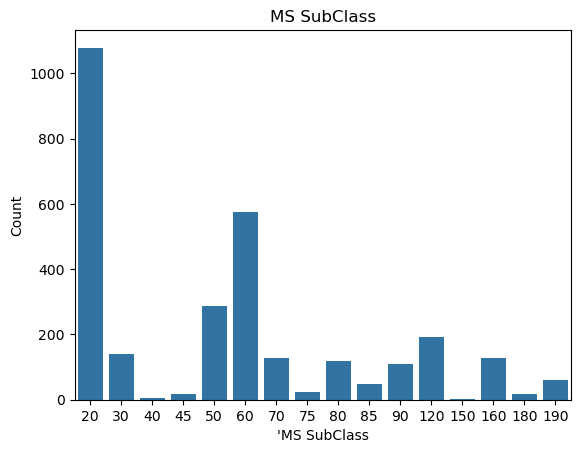

In [195]:
# handling the value of ms subclass with the help of one hot enconding
sns.countplot(x='MS SubClass', data= dataset)
plt.title("MS SubClass")
plt.xlabel("'MS SubClass")
plt.ylabel('Count')
plt.show()


In [320]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 65 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order           2930 non-null   int64  
 1   MS SubClass     2930 non-null   int64  
 2   MS Zoning       2930 non-null   object 
 3   Lot Frontage    2930 non-null   float64
 4   Lot Area        2930 non-null   int64  
 5   Lot Shape       2930 non-null   object 
 6   Land Contour    2930 non-null   object 
 7   Lot Config      2930 non-null   object 
 8   Land Slope      2930 non-null   object 
 9   Neighborhood    2930 non-null   object 
 10  Condition 1     2930 non-null   object 
 11  Condition 2     2930 non-null   object 
 12  Bldg Type       2930 non-null   object 
 13  House Style     2930 non-null   object 
 14  Overall Qual    2930 non-null   int64  
 15  Year Built      2930 non-null   int64  
 16  Year Remod/Add  2930 non-null   int64  
 17  Roof Style      2930 non-null   o

In [539]:
#dataset['Mas Vnr Type'] = dataset['Mas Vnr Type'].fillna('')
##sns.countplot(x='Mas Vnr Type',data = dataset)
#plt.title('Mas Vnr Type')
#plt.xlabel('Mas Vnr Type')
##plt.ylabel("count")
#plt.show(


In [541]:
print(dataset.dtypes.head(50))

Order                int64
MS SubClass          int64
MS Zoning           object
Lot Frontage       float64
Lot Area             int64
Street              object
Lot Shape           object
Land Contour        object
Utilities           object
Lot Config          object
Land Slope          object
Neighborhood        object
Condition 1         object
Condition 2         object
Bldg Type           object
House Style         object
Overall Qual         int64
Overall Cond         int64
Year Built           int64
Year Remod/Add       int64
Roof Style          object
Roof Matl           object
Exterior 1st        object
Exterior 2nd        object
Mas Vnr Type        object
Mas Vnr Area       float64
Exter Qual          object
Exter Cond          object
Foundation          object
Bsmt Qual           object
Bsmt Cond           object
Bsmt Exposure       object
BsmtFin Type 1      object
BsmtFin SF 1       float64
BsmtFin Type 2      object
BsmtFin SF 2       float64
Bsmt Unf SF        float64
T

In [543]:
print(dataset.dtypes.tail(32))

Full Bath           int64
Half Bath           int64
Bedroom AbvGr       int64
Kitchen AbvGr       int64
Kitchen Qual       object
TotRms AbvGrd       int64
Functional         object
Fireplaces          int64
Fireplace Qu       object
Garage Type        object
Garage Yr Blt     float64
Garage Finish      object
Garage Cars       float64
Garage Area       float64
Garage Qual        object
Garage Cond        object
Paved Drive        object
Wood Deck SF        int64
Open Porch SF       int64
Enclosed Porch      int64
3Ssn Porch          int64
Screen Porch        int64
Pool Area           int64
Pool QC            object
Fence              object
Misc Feature       object
Misc Val            int64
Mo Sold             int64
Yr Sold             int64
Sale Type          object
Sale Condition     object
SalePrice           int64
dtype: object


In [545]:
print(dataset.dtypes)

Order               int64
MS SubClass         int64
MS Zoning          object
Lot Frontage      float64
Lot Area            int64
                   ...   
Mo Sold             int64
Yr Sold             int64
Sale Type          object
Sale Condition     object
SalePrice           int64
Length: 80, dtype: object


In [548]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 80 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   MS SubClass      2930 non-null   int64  
 2   MS Zoning        2930 non-null   object 
 3   Lot Frontage     2440 non-null   float64
 4   Lot Area         2930 non-null   int64  
 5   Street           2930 non-null   object 
 6   Lot Shape        2930 non-null   object 
 7   Land Contour     2930 non-null   object 
 8   Utilities        2930 non-null   object 
 9   Lot Config       2930 non-null   object 
 10  Land Slope       2930 non-null   object 
 11  Neighborhood     2930 non-null   object 
 12  Condition 1      2930 non-null   object 
 13  Condition 2      2930 non-null   object 
 14  Bldg Type        2930 non-null   object 
 15  House Style      2930 non-null   object 
 16  Overall Qual     2930 non-null   int64  
 17  Overall Cond  

In [550]:
# First way we can see only numerical clumns correlation 
dataset_numerical = dataset.select_dtypes(include=['number'])

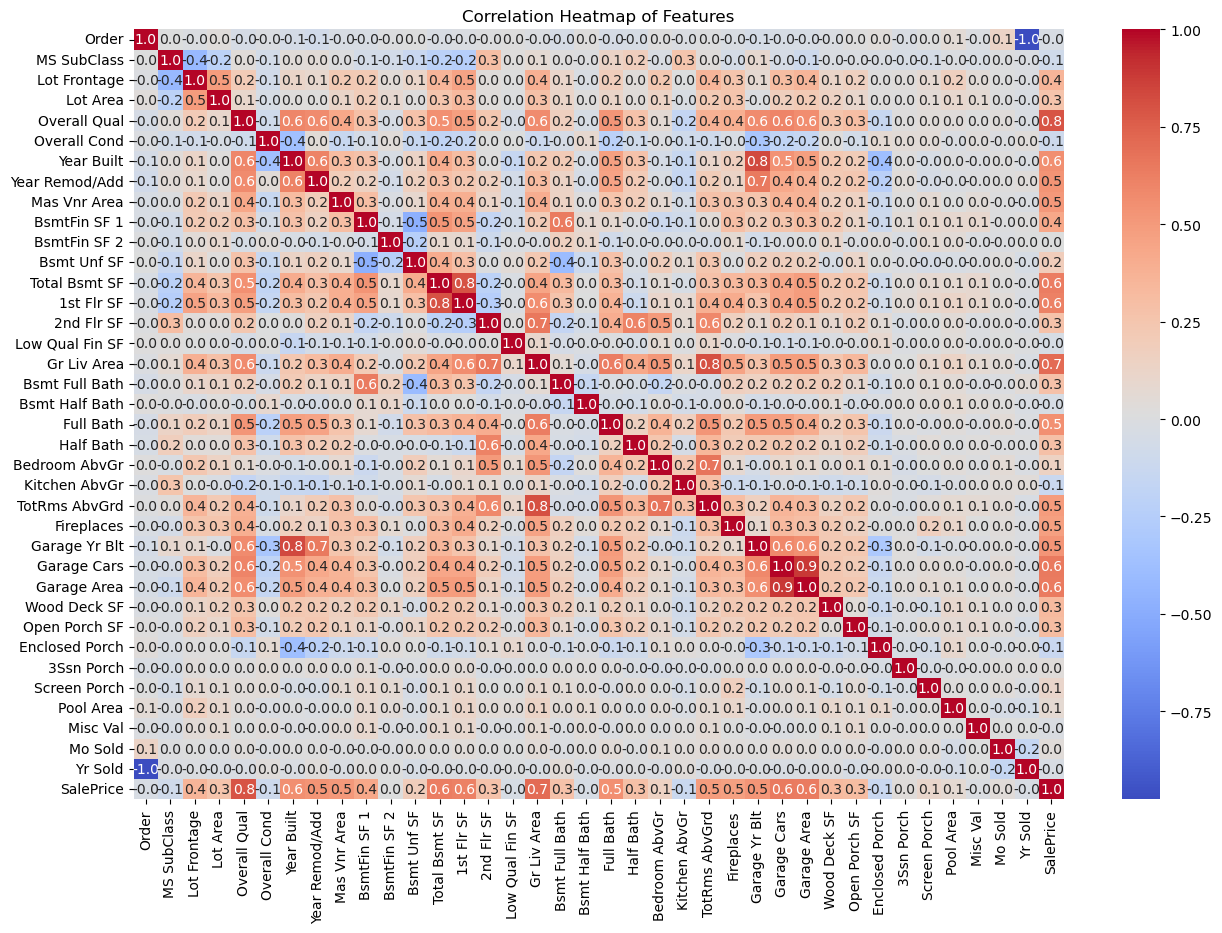

In [552]:
# Correlatio  of numerical features only
corr_matrix = dataset_numerical.corr()
plt.figure(figsize=(15,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".1f")
plt.title("Correlation Heatmap of Features")
plt.show()

In [553]:
saleprice_corr = corr_matrix['SalePrice'].sort_values(ascending=False)
saleprice_corr

SalePrice          1.000000
Overall Qual       0.799262
Gr Liv Area        0.706780
Garage Cars        0.647877
Garage Area        0.640401
Total Bsmt SF      0.632280
1st Flr SF         0.621676
Year Built         0.558426
Full Bath          0.545604
Year Remod/Add     0.532974
Garage Yr Blt      0.526965
Mas Vnr Area       0.508285
TotRms AbvGrd      0.495474
Fireplaces         0.474558
BsmtFin SF 1       0.432914
Lot Frontage       0.357318
Wood Deck SF       0.327143
Open Porch SF      0.312951
Half Bath          0.285056
Bsmt Full Bath     0.276050
2nd Flr SF         0.269373
Lot Area           0.266549
Bsmt Unf SF        0.182855
Bedroom AbvGr      0.143913
Screen Porch       0.112151
Pool Area          0.068403
Mo Sold            0.035259
3Ssn Porch         0.032225
BsmtFin SF 2       0.005891
Misc Val          -0.015691
Yr Sold           -0.030569
Order             -0.031408
Bsmt Half Bath    -0.035835
Low Qual Fin SF   -0.037660
MS SubClass       -0.085092
Overall Cond      -0

In [554]:
dataset.isnull().sum().head(50)

Order                 0
MS SubClass           0
MS Zoning             0
Lot Frontage        490
Lot Area              0
Street                0
Lot Shape             0
Land Contour          0
Utilities             0
Lot Config            0
Land Slope            0
Neighborhood          0
Condition 1           0
Condition 2           0
Bldg Type             0
House Style           0
Overall Qual          0
Overall Cond          0
Year Built            0
Year Remod/Add        0
Roof Style            0
Roof Matl             0
Exterior 1st          0
Exterior 2nd          0
Mas Vnr Type       1775
Mas Vnr Area         23
Exter Qual            0
Exter Cond            0
Foundation            0
Bsmt Qual            80
Bsmt Cond            80
Bsmt Exposure        83
BsmtFin Type 1       80
BsmtFin SF 1          1
BsmtFin Type 2       81
BsmtFin SF 2          1
Bsmt Unf SF           1
Total Bsmt SF         1
Heating               0
Heating QC            0
Central Air           0
Electrical      

In [556]:
dataset

,Order,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,20,RL,141.0,31770,Pave,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,20,RL,93.0,11160,Pave,Reg,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,80,RL,37.0,7937,Pave,IR1,Lvl,AllPub,CulDSac,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,20,RL,NaN,8885,Pave,IR1,Low,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,85,RL,62.0,10441,Pave,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,20,RL,77.0,10010,Pave,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 80 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   MS SubClass      2930 non-null   int64  
 2   MS Zoning        2930 non-null   object 
 3   Lot Frontage     2440 non-null   float64
 4   Lot Area         2930 non-null   int64  
 5   Street           2930 non-null   object 
 6   Lot Shape        2930 non-null   object 
 7   Land Contour     2930 non-null   object 
 8   Utilities        2930 non-null   object 
 9   Lot Config       2930 non-null   object 
 10  Land Slope       2930 non-null   object 
 11  Neighborhood     2930 non-null   object 
 12  Condition 1      2930 non-null   object 
 13  Condition 2      2930 non-null   object 
 14  Bldg Type        2930 non-null   object 
 15  House Style      2930 non-null   object 
 16  Overall Qual     2930 non-null   int64  
 17  Overall Cond  